In [1]:
# Tasks 1. Data Loading and Inspection

In [5]:
import pandas as pd
# Load data
df = pd.read_csv ('D:\BA\BITSoM BA Assignment Datasets\ml-assessment-nishant-saxena\data\q1_heart_disease.csv')

#Shape
print("shape:", df.shape)

#data types
print("\nData Types:\n", df.dtypes)

#Missing values
print("\nMissing Values:\n", df.isnull().sum())

#first 5 rows
df.head()

shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


<>:3: SyntaxWarning: invalid escape sequence '\B'
<>:3: SyntaxWarning: invalid escape sequence '\B'
C:\Users\nisha\AppData\Local\Temp\ipykernel_37040\546298404.py:3: SyntaxWarning: invalid escape sequence '\B'
  df = pd.read_csv ('D:\BA\BITSoM BA Assignment Datasets\ml-assessment-nishant-saxena\data\q1_heart_disease.csv')


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [ ]:
# Task 2. Exploratory Data Analysis

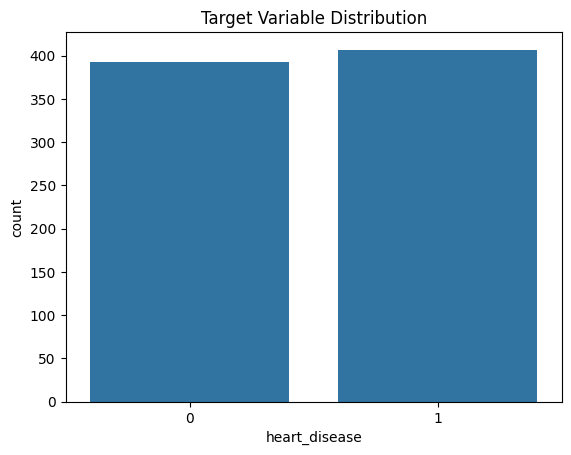

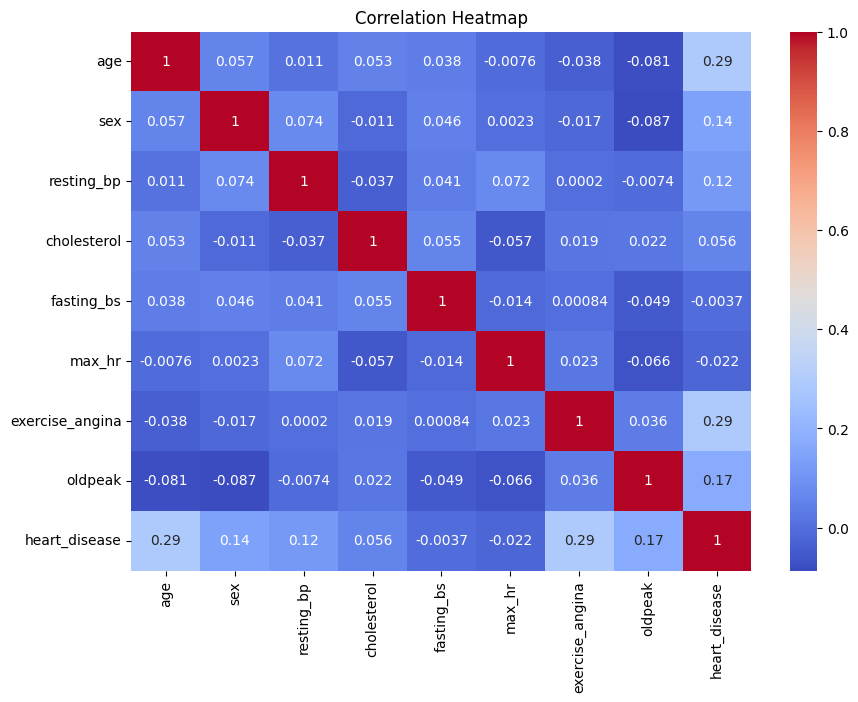

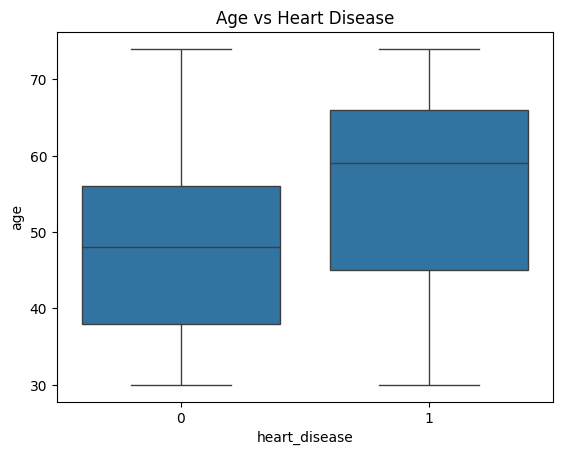

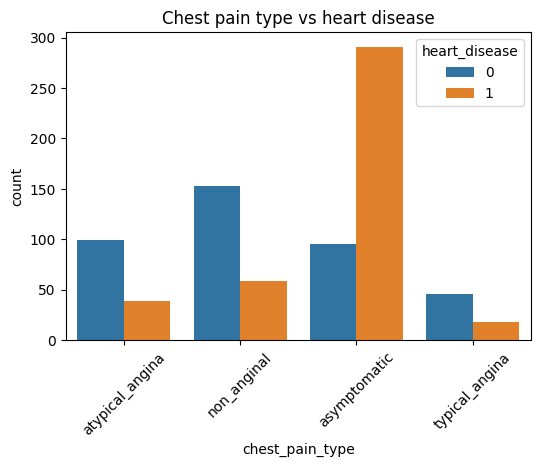

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1 target distribution
sns.countplot(x='heart_disease', data=df)
plt.title("Target Variable Distribution")
plt.show()

#2 correlation heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#3 age vs heart Disease
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

#4 chest pain type vs heart disease
plt.figure(figsize=(6,4))
sns.countplot(x='chest_pain_type', hue='heart_disease', data=df)
plt.xticks(rotation=45)
plt.title('Chest pain type vs heart disease')
plt.show()

In [9]:
# Task 3. Data Preprocessing

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# handle missing values (median strategy)
df = df.fillna(df.median(numeric_only=True))

# one-hot encoding
df = pd.get_dummies(df, drop_first=True)

#split feature & target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, stratify=y, random_state=42
)
# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Task 4. Model Training

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Train
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [ ]:
# Task 5. Model Evaluation 

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

# Evaluate all
evaluate_model(dt, "Decision Tree")
evaluate_model(rf, "Random Forest")
evaluate_model(gb, "Gradient Boosting")


Decision Tree
Confusion Matrix:
 [[57 22]
 [25 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


Random Forest
Confusion Matrix:
 [[61 18]
 [15 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting
Confusion Matrix:
 [[61 18]
 [19 62]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
  

### Model Evaluation Conclusion

Among all three models, **Random Forest performs the best**.

- It has the highest **F1-score (~0.79–0.80)** compared to Decision Tree (~0.71) and Gradient Boosting (~0.77).
- It also achieves a strong balance between **precision and recall** for both classes.
- From the confusion matrix, Random Forest has **fewer misclassifications** (both false positives and false negatives).

In this problem, recall is important to correctly identify patients with heart disease, and Random Forest maintains a high recall (0.81) along with good precision.

### Final Decision:
**Random Forest is the best-performing model** as it provides the highest F1-score and the most balanced performance across all evaluation metrics.

In [ ]:
# Task 6. Hyperparameter Tuning

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=5,
                    scoring='f1')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}


In [18]:
# Evaluate tuned model
best_model = grid.best_estimator_
evaluate_model(best_model, "Tuned Random Forest")


Tuned Random Forest
Confusion Matrix:
 [[58 21]
 [16 65]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.73      0.76        79
           1       0.76      0.80      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



### Hyperparameter Tuning Conclusion

We tuned the Random Forest model using GridSearchCV.

- **Best Parameters:** max_depth = 10, n_estimators = 100

### Comparison with Baseline:
- **Baseline Random Forest F1-score:** ~0.79–0.80  
- **Tuned Random Forest F1-score:** ~0.77–0.78  

The tuned model shows a slight decrease in performance compared to the baseline. While tuning helped control model complexity, it did not improve test performance in this case.

### Final Conclusion:
**The baseline Random Forest model performs better than the tuned version**, so it remains the preferred model for this task.